# Control-Theoretic Analysis of the Resonate-and-Fire Neuron

This notebook treats a Resonate-and-Fire (RF) neuron as a driven, damped harmonic oscillator (RLC analog)
and analyzes it using classical control theory tools. We interpret the membrane voltage $v(t)$ as the output
and the input current $I(t)$ as the forcing function.

Key model equation:
$$ \ddot{v} + 2\zeta\omega_n\dot{v} + \omega_n^2 v = I(t) $$


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'font.size': 11,
})


## Section 1: Fundamental Control Theory of the RF Neuron

### State-Space Representation
Let $x_1 = v$ and $x_2 = \dot{v}$. Then
$$
\dot{x}_1 = x_2, \quad
\dot{x}_2 = -2\zeta\omega_n x_2 - \omega_n^2 x_1 + I(t)
$$

So the state-space form is
$$
\dot{\mathbf{x}} = \mathbf{A}\mathbf{x} + \mathbf{B}I(t), \quad
v = \mathbf{C}\mathbf{x}
$$
with
$$
\mathbf{A} = \begin{bmatrix} 0 & 1 \;\; -\omega_n^2 & -2\zeta\omega_n \end{bmatrix},
\quad
\mathbf{B} = \begin{bmatrix} 0 \;\; 1 \end{bmatrix},
\quad
\mathbf{C} = \begin{bmatrix} 1 & 0 \end{bmatrix}.
$$

### Transfer Function
Taking the Laplace transform with zero initial conditions:
$$
H(s) = \frac{V(s)}{I(s)} = \frac{1}{s^2 + 2\zeta\omega_n s + \omega_n^2}.
$$

The quality factor is
$$
Q = \frac{1}{2\zeta}.
$$
A smaller $\zeta$ (higher $Q$) yields stronger resonance but longer ringing.

### Impulse Response
For input $I(t) = \delta(t)$ and $0 < \zeta < 1$, the impulse response is
$$
h(t) = \frac{1}{\omega_d} e^{-\zeta\omega_n t} \sin(\omega_d t),
\quad \omega_d = \omega_n\sqrt{1-\zeta^2}.
$$


In [10]:
# Symbolic transfer function and impulse response
s, zeta, wn, t = sp.symbols('s zeta wn t', positive=True)
H = 1 / (s**2 + 2*zeta*wn*s + wn**2)
sp.simplify(H)


1/(s**2 + 2*s*wn*zeta + wn**2)

In [11]:
# Inverse Laplace (underdamped case)
wd = sp.sqrt(wn**2 * (1 - zeta**2))
h_t = sp.exp(-zeta*wn*t) * sp.sin(wd*t) / wd
sp.simplify(h_t)


exp(-t*wn*zeta)*sin(t*wn*sqrt(1 - zeta**2))/(wn*sqrt(1 - zeta**2))

### Numerical Impulse Response and Bode Plot
The RF neuron behaves like a resonant second-order system with a pronounced peak near $\omega_n$.
The Bode magnitude shows this resonance and the phase transition around the natural frequency.


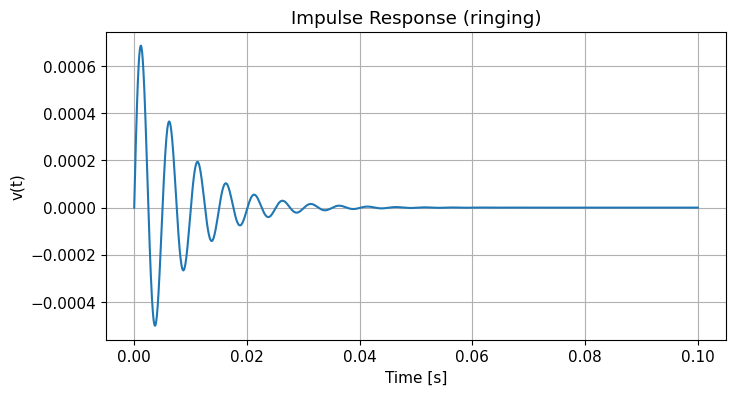

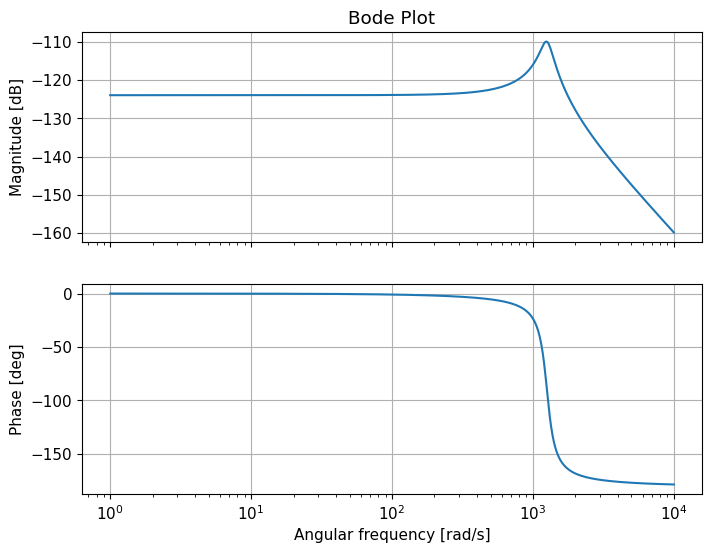

In [12]:
# Nominal parameters
wn_val = 2 * np.pi * 200.0  # rad/s
zeta_val = 0.1

sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_val, wn_val**2])

# Impulse response
t_imp, y_imp = signal.impulse(sys, T=np.linspace(0, 0.1, 2000))
plt.plot(t_imp, y_imp)
plt.title('Impulse Response (ringing)')
plt.xlabel('Time [s]')
plt.ylabel('v(t)')
plt.show()

# Bode plot
w = np.logspace(0, 4, 800)
w, mag, phase = signal.bode(sys, w=w)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
ax[0].semilogx(w, mag)
ax[0].set_ylabel('Magnitude [dB]')
ax[0].set_title('Bode Plot')
ax[1].semilogx(w, phase)
ax[1].set_ylabel('Phase [deg]')
ax[1].set_xlabel('Angular frequency [rad/s]')
plt.show()


### Parametric Analysis ($\omega_n$ and $\zeta$)
- Increasing $\omega_n$ shifts the resonant peak to higher frequencies.
- Increasing $\zeta$ lowers the peak and broadens the bandwidth.
- The approximate bandwidth relates to the quality factor: $BW \approx \omega_n / Q$.


### State-Space Stability and Eigenvalues (Symplectic Euler note)
A common symplectic Euler implementation uses the state ordering $x = [\dot{v}, v]^T$, which yields
$$
\mathbf{A} = \begin{bmatrix} -2\zeta\omega_n & -\omega_n^2 \;\; 1 & 0 \end{bmatrix}.
$$
If $v$ is rescaled by $\omega_n^2$, an equivalent form often appears as
$$
\mathbf{A} = \begin{bmatrix} -2\zeta\omega_n & -1 \;\; \omega_n^2 & 0 \end{bmatrix}.
$$
In all cases, the eigenvalues are
$$
\lambda = -\zeta\omega_n \pm j\omega_d, \quad \omega_d = \omega_n\sqrt{1-\zeta^2},
$$
and stability requires a negative real part.


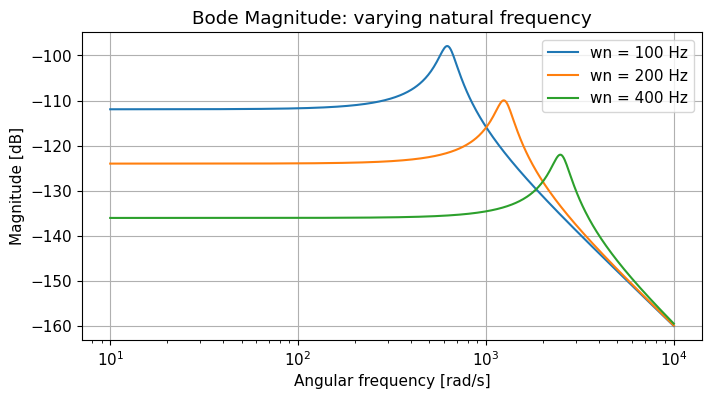

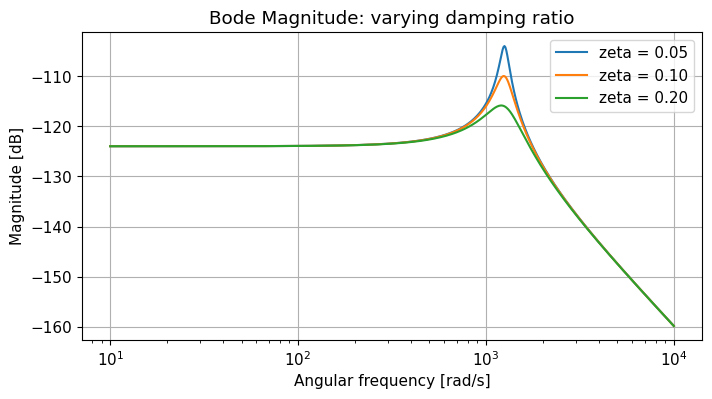

In [17]:
w = np.logspace(1, 4, 600)
zeta_val = 0.1
wn_list = [2*np.pi*100, 2*np.pi*200, 2*np.pi*400]
zeta_list = [0.05, 0.1, 0.2]

# Vary natural frequency
plt.figure(figsize=(8, 4))
for wn_val in wn_list:
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_val, wn_val**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w, mag, label=f'wn = {wn_val/(2*np.pi):.0f} Hz')
plt.title('Bode Magnitude: varying natural frequency')
plt.xlabel('Angular frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.legend()
plt.show()

# Vary damping ratio
plt.figure(figsize=(8, 4))
for zeta_val in zeta_list:
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_list[1], wn_list[1]**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w, mag, label=f'zeta = {zeta_val:.2f}')
plt.title('Bode Magnitude: varying damping ratio')
plt.xlabel('Angular frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.legend()
plt.show()


## Section 2: Echolocation and Distance Measurement (Bat Model)

We model a dual-impulse input representing the corollary discharge (inhibitory) and the returning echo
(excitatory):
$$
I(t) = -A_{inh}\delta(t) + A_{exc}\delta(t - \tau)
$$
where $\tau$ is the time-of-flight (ToF).

The output is a superposition of impulse responses: 
$$
v(t) = -A_{inh} h(t) + A_{exc} h(t-\tau).
$$
A resonance match occurs when the neuron's natural period $T = 2\pi/\omega_n$ aligns with $\tau$,
producing constructive interference and a large peak (phase kick).


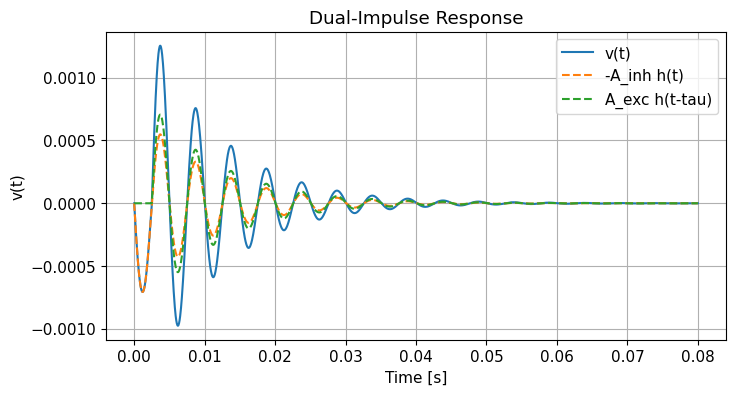

In [18]:
def impulse_response(t, wn, zeta):
    wd = wn * np.sqrt(1 - zeta**2)
    h = np.zeros_like(t)
    mask = t >= 0
    h[mask] = np.exp(-zeta*wn*t[mask]) * np.sin(wd*t[mask]) / wd
    return h

# Dual-impulse parameters
wn_val = 2 * np.pi * 200.0
zeta_val = 0.08
A_inh = 1.0
A_exc = 1.0
tau = 0.5 / 200.0  # seconds

t = np.linspace(0, 0.08, 2000)
h = impulse_response(t, wn_val, zeta_val)
h_shift = impulse_response(t - tau, wn_val, zeta_val)
v = -A_inh * h + A_exc * h_shift

plt.plot(t, v, label='v(t)')
plt.plot(t, -A_inh*h, '--', label='-A_inh h(t)')
plt.plot(t, A_exc*h_shift, '--', label='A_exc h(t-tau)')
plt.title('Dual-Impulse Response')
plt.xlabel('Time [s]')
plt.ylabel('v(t)')
plt.legend()
plt.show()


### Distance Tuning and a Bank of Neurons
Assuming a round-trip delay $\tau = 2d/c$ (distance $d$, propagation speed $c$),
the resonance match condition is
$$
T = \frac{2\pi}{\omega_n} \approx \tau = \frac{2d}{c}.
$$
So a bank of neurons tuned to distances $d$ should use
$$
\omega_n(d) = \frac{2\pi}{\tau} = \frac{\pi c}{d}.
$$
For acoustic echolocation, a typical choice is $c = 343\ 	ext{m/s}$.
For radar, set $c = 3\times10^8\ 	ext{m/s}$.


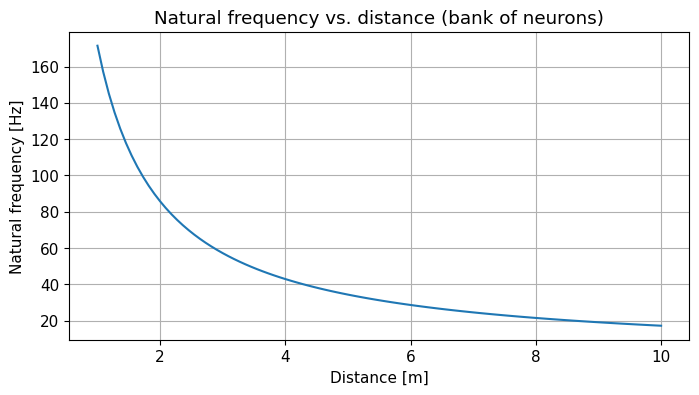

d = 1.0 m -> wn = 1077.57 rad/s (171.50 Hz)
d = 1.1 m -> wn = 987.77 rad/s (157.21 Hz)
d = 1.2 m -> wn = 911.79 rad/s (145.12 Hz)
d = 1.3 m -> wn = 846.66 rad/s (134.75 Hz)
d = 1.4 m -> wn = 790.22 rad/s (125.77 Hz)
d = 1.5 m -> wn = 740.83 rad/s (117.91 Hz)
d = 1.5 m -> wn = 697.25 rad/s (110.97 Hz)
d = 1.6 m -> wn = 658.51 rad/s (104.81 Hz)
d = 1.7 m -> wn = 623.85 rad/s (99.29 Hz)
d = 1.8 m -> wn = 592.66 rad/s (94.32 Hz)
d = 1.9 m -> wn = 564.44 rad/s (89.83 Hz)
d = 2.0 m -> wn = 538.78 rad/s (85.75 Hz)
d = 2.1 m -> wn = 515.36 rad/s (82.02 Hz)
d = 2.2 m -> wn = 493.88 rad/s (78.60 Hz)
d = 2.3 m -> wn = 474.13 rad/s (75.46 Hz)
d = 2.4 m -> wn = 455.89 rad/s (72.56 Hz)
d = 2.5 m -> wn = 439.01 rad/s (69.87 Hz)
d = 2.5 m -> wn = 423.33 rad/s (67.38 Hz)
d = 2.6 m -> wn = 408.73 rad/s (65.05 Hz)
d = 2.7 m -> wn = 395.11 rad/s (62.88 Hz)
d = 2.8 m -> wn = 382.36 rad/s (60.85 Hz)
d = 2.9 m -> wn = 370.41 rad/s (58.95 Hz)
d = 3.0 m -> wn = 359.19 rad/s (57.17 Hz)
d = 3.1 m -> wn = 348.62 

In [22]:
# Bank of neuron frequencies for distances 1m to 10m
c = 343.0  # m/s (sound); swap to 3e8 for radar
d = np.linspace(1.0, 10.0, 100)
tau = 2 * d / c
wn = 2 * np.pi / tau

plt.plot(d, wn / (2*np.pi))
plt.title('Natural frequency vs. distance (bank of neurons)')
plt.xlabel('Distance [m]')
plt.ylabel('Natural frequency [Hz]')
plt.show()

for di, wni in zip(d, wn):
    print(f'd = {di:.1f} m -> wn = {wni:.2f} rad/s ({wni/(2*np.pi):.2f} Hz)')


### Optimization Trade-Off: Temporal Precision vs. Frequency Selectivity
- High damping (large $\zeta$): fast decay, sharper timing, weaker resonance.
- Low damping (small $\zeta$): strong resonance, better frequency selectivity, longer ringing.

Below we compare impulse responses at different damping ratios to illustrate this trade-off.


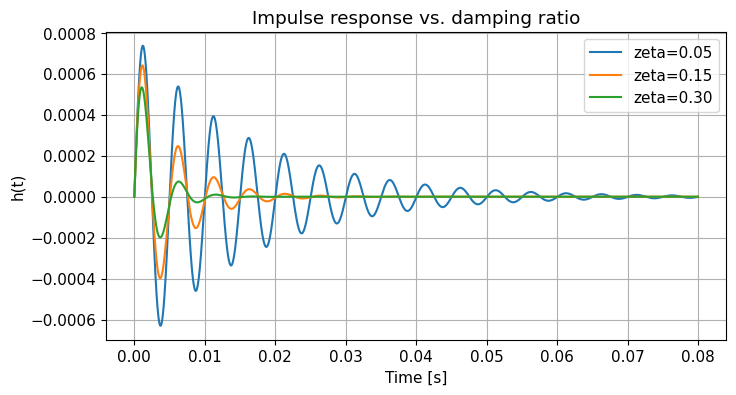

In [16]:
wn_val = 2 * np.pi * 200.0
t = np.linspace(0, 0.08, 2000)

plt.figure(figsize=(8, 4))
for zeta_val in [0.05, 0.15, 0.3]:
    h = impulse_response(t, wn_val, zeta_val)
    plt.plot(t, h, label=f'zeta={zeta_val:.2f}')
plt.title('Impulse response vs. damping ratio')
plt.xlabel('Time [s]')
plt.ylabel('h(t)')
plt.legend()
plt.show()


## Control-Theory Anchors Recap
1. **Quality Factor**: $Q = 1/(2\zeta)$ controls resonance sharpness and ringing duration.
2. **Phase Kick**: the echo triggers a large response if it arrives near the peak of the ongoing oscillation.
3. **Stability**: the eigenvalues of $\mathbf{A}$ are $\lambda = -\zeta\omega_n \pm j\omega_d$.
   The real part must be negative for stability (decaying oscillations).


## Extended Analysis: Damping, Tuned Frequency, and Distance Mapping

### 1) Damped Frequency vs. Distance
For a neuron tuned to distance $d$, the round-trip delay is $\tau = 2d/c$, so
$$
\omega_n(d) = \frac{2\pi}{\tau} = \frac{\pi c}{d}.
$$
With damping ratio $\zeta$, the **damped frequency** is
$$
\omega_d(d,\zeta) = \omega_n(d)\sqrt{1-\zeta^2}.
$$
Below we plot the damped frequency versus distance for multiple values of $\zeta$.


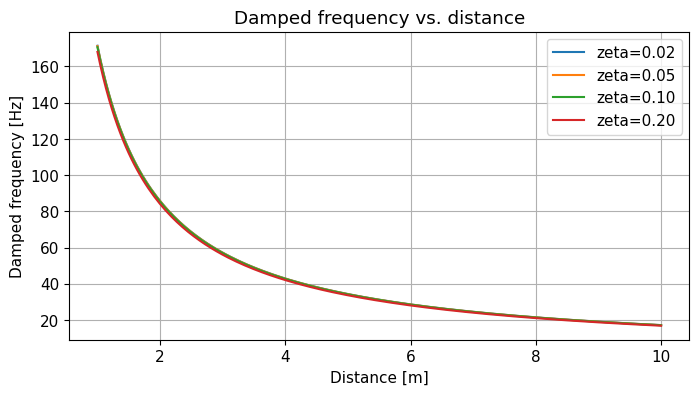

In [23]:
# Damped frequency vs. distance for multiple zeta values
c = 343.0  # m/s (sound); swap to 3e8 for radar
d = np.linspace(1.0, 10.0, 200)
wn = np.pi * c / d

zeta_vals = [0.02, 0.05, 0.1, 0.2]
plt.figure(figsize=(8, 4))
for zeta_val in zeta_vals:
    wd = wn * np.sqrt(1 - zeta_val**2)
    plt.plot(d, wd/(2*np.pi), label=f'zeta={zeta_val:.2f}')

plt.title('Damped frequency vs. distance')
plt.xlabel('Distance [m]')
plt.ylabel('Damped frequency [Hz]')
plt.legend()
plt.show()


### 2) Choosing $Q$ (and $\zeta$) from Distance Spacing
If neurons are placed to cover distances $d_i$ with spacing $\Delta d$, a natural choice is to set each
neuron's bandwidth to match the spacing in frequency. For lightly damped systems,
$$
BW \approx \frac{\omega_n}{Q} \approx 2\zeta\omega_n.
$$
Using $\omega_n(d) = \pi c / d$, the local frequency spacing from a distance step is
$$
\Delta\omega \approx \left|\frac{d\omega_n}{dd}\right|\Delta d = \frac{\pi c}{d^2}\Delta d.
$$
So a practical tuning rule is
$$
Q(d) \approx \frac{\omega_n(d)}{\Delta\omega} = \frac{d}{\Delta d},
\quad
\zeta(d) \approx \frac{1}{2Q(d)} = \frac{\Delta d}{2d}.
$$
This keeps each neuron's resonance peak aligned with its desired distance and reduces excessive overlap.

We compute $Q$ and $\zeta$ for a bank of neurons and overlay their Bode magnitudes to verify that
the peak aligns with the desired tuned frequency.


In [ ]:
# Bank of neurons: choose Q and zeta from distance spacing
c = 343.0  # m/s (sound)
d_min, d_max, N = 1.0, 10.0, 8
d_bank = np.linspace(d_min, d_max, N)
delta_d = d_bank[1] - d_bank[0]

# Desired natural frequencies from distance
wn_bank = np.pi * c / d_bank

# Q and zeta from spacing rule (lightly damped approximation)
Q_bank = d_bank / delta_d
zeta_bank = 1.0 / (2.0 * Q_bank)

# Keep zeta in resonant regime (zeta < 1/sqrt(2))
zeta_bank = np.minimum(zeta_bank, 0.49)

# Bode plots for all tuned neurons
w = np.logspace(1, 5, 1200)  # rad/s
plt.figure(figsize=(8, 4))
for di, wn_i, zeta_i in zip(d_bank, wn_bank, zeta_bank):
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_i*wn_i, wn_i**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w/(2*np.pi), mag, label=f'd={di:.1f} m, zeta={zeta_i:.3f}')

plt.title('Bode magnitude: tuned neuron bank')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.legend(fontsize=8)
plt.show()

print('Neuron bank parameters:')
for di, wn_i, Q_i, zeta_i in zip(d_bank, wn_bank, Q_bank, zeta_bank):
    print(f'd={di:.2f} m -> wn={wn_i:.2f} rad/s ({wn_i/(2*np.pi):.2f} Hz), Q={Q_i:.2f}, zeta={zeta_i:.4f}')


### 3) Formalized Distance-to-Tuning Equations
**Time-of-Flight and Natural Frequency**
$$
\tau(d) = \frac{2d}{c},
\quad
\omega_n(d) = \frac{2\pi}{\tau(d)} = \frac{\pi c}{d}.
$$

**Damped Frequency and Resonant Peak**
$$
\omega_d(d,\zeta) = \omega_n(d)\sqrt{1-\zeta^2},
$$
and for $\zeta < 1/\sqrt{2}$, the magnitude peak occurs near
$$
\omega_{peak}(d,\zeta) = \omega_n(d)\sqrt{1-2\zeta^2}.
$$

**Quality Factor and Bandwidth**
$$
Q = \frac{1}{2\zeta},
\quad
BW \approx \frac{\omega_n}{Q} \approx 2\zeta\omega_n.
$$

**Distance-Spacing Rule (Tuning for a Bank)**
If neurons are spaced by $\Delta d$, then the corresponding frequency spacing is
$$
\Delta\omega(d) \approx \left|\frac{d\omega_n}{dd}\right|\Delta d = \frac{\pi c}{d^2}\Delta d.
$$
Choosing $BW \approx \Delta\omega$ gives
$$
Q(d) \approx \frac{\omega_n(d)}{\Delta\omega(d)} = \frac{d}{\Delta d},
\quad
\zeta(d) \approx \frac{\Delta d}{2d}.
$$
